In [1]:
# ─── Data Handling ───────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualisation ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Machine Learning ────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ─── Settings ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean and consistent
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv(r"C:\Users\ssmsd\Downloads\flights.csv")

In [3]:
print(f"Shape: {df.shape}")           # rows and columns
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (15000, 22)

Columns:
['airline_name', 'date_of_journey', 'month', 'month_name', 'day_of_week', 'is_weekend', 'Source', 'destination', 'route', 'Origin', 'Stop_1', 'Stop_2', 'Stop3', 'Total_stops', 'dep_time', 'Arrival_time', 'Duration', 'Duration_mins', 'Route_Type', 'Additional_info', 'Price', 'Price_Per_Min']


,airline_name,date_of_journey,month,month_name,day_of_week,is_weekend,Source,destination,route,Origin,...,Stop3,Total_stops,dep_time,Arrival_time,Duration,Duration_mins,Route_Type,Additional_info,Price,Price_Per_Min
0,AirAsia India,25-02-2024,2,February,Sunday,Yes,Guwahati,Indore,GUW-NAG-MUM-RAI-IND,GUW,...,RAI,3 stops,01:39,14:15,3h 15min,195,Domestic_Long,Red-eye flight,14170,72.67
1,TruJet,01-03-2021,3,March,Monday,No,Nagpur,Pune,NAG-PUN,NAG,...,NaN,non-stop,06:48,03:21,1h 0min,60,Domestic_Short,1 Long layover,10295,171.58
2,Star Air,11-04-2024,4,April,Thursday,No,Ahmedabad,Varanasi,AHM-PUN-BAN-VAR,AHM,...,VAR,2 stops,08:54,15:50,14h 30min,870,Domestic_Long,In-flight meal not included,9165,10.53
3,SpiceJet,13-03-2019,3,March,Wednesday,No,Patna,Indore,PAT-LUC-GOA-BHU-IND,PAT,...,BHU,3 stops,18:09,08:23,7h 15min,435,Domestic_Long,No info,9944,22.86
4,SpiceJet,22-06-2023,6,June,Thursday,No,Raipur,Mumbai,RAI-GOA-MUM,RAI,...,NaN,1 stop,15:05,05:52,15h 30min,930,Domestic_Long,1 Long layover,9474,10.19


In [4]:
# ─── Basic info ───────────────────────────────────────────
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()

=== SHAPE ===
(15000, 22)

=== DATA TYPES ===
airline_name        object
date_of_journey     object
month                int64
month_name          object
day_of_week         object
is_weekend          object
Source              object
destination         object
route               object
Origin              object
Stop_1              object
Stop_2              object
Stop3               object
Total_stops         object
dep_time            object
Arrival_time        object
Duration            object
Duration_mins        int64
Route_Type          object
Additional_info     object
Price                int64
Price_Per_Min      float64
dtype: object

=== NULL VALUES ===
airline_name          0
date_of_journey       0
month                 0
month_name            0
day_of_week           0
is_weekend            0
Source                0
destination           0
route                 0
Origin                0
Stop_1                0
Stop_2             3766
Stop3              7447
Total_stops  

,month,Duration_mins,Price,Price_Per_Min
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,6.515933,502.052000,9355.349000,30.408689
std,3.449793,260.692827,3290.049097,33.429971
min,1.000000,60.000000,2502.000000,2.660000
25%,3.000000,270.000000,6852.000000,12.170000
50%,7.000000,495.000000,9354.000000,18.560000
75%,9.000000,735.000000,11755.000000,33.810000
max,12.000000,945.000000,17900.000000,296.220000


In [5]:
df = df.drop(columns=['Stop_1', 'Stop_2', 'Stop3'])

In [6]:
df.columns

Index(['airline_name', 'date_of_journey', 'month', 'month_name', 'day_of_week',
       'is_weekend', 'Source', 'destination', 'route', 'Origin', 'Total_stops',
       'dep_time', 'Arrival_time', 'Duration', 'Duration_mins', 'Route_Type',
       'Additional_info', 'Price', 'Price_Per_Min'],
      dtype='object')

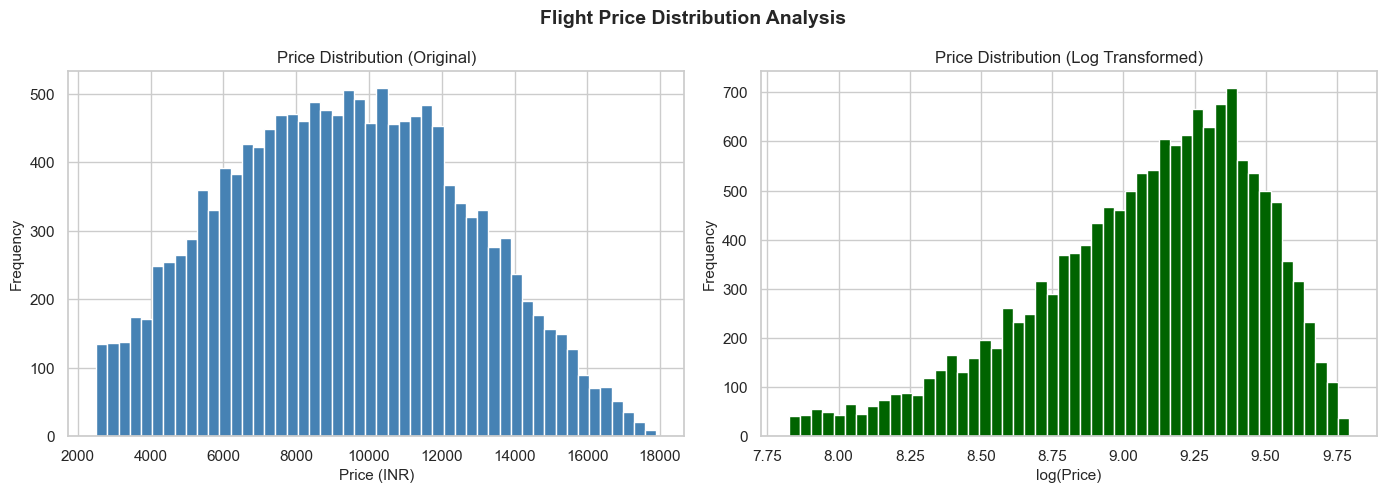

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')

# Log transformed distribution
axes[1].hist(np.log1p(df['Price']), bins=50, color='darkgreen', edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Flight Price Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
df['price_log'] = np.log1p(df['Price'])
print("Log transform applied successfully")
print(f"Original price range: {df['Price'].min()} to {df['Price'].max()}")
print(f"Log price range: {df['price_log'].min():.2f} to {df['price_log'].max():.2f}")

Log transform applied successfully
Original price range: 2502 to 17900
Log price range: 7.83 to 9.79


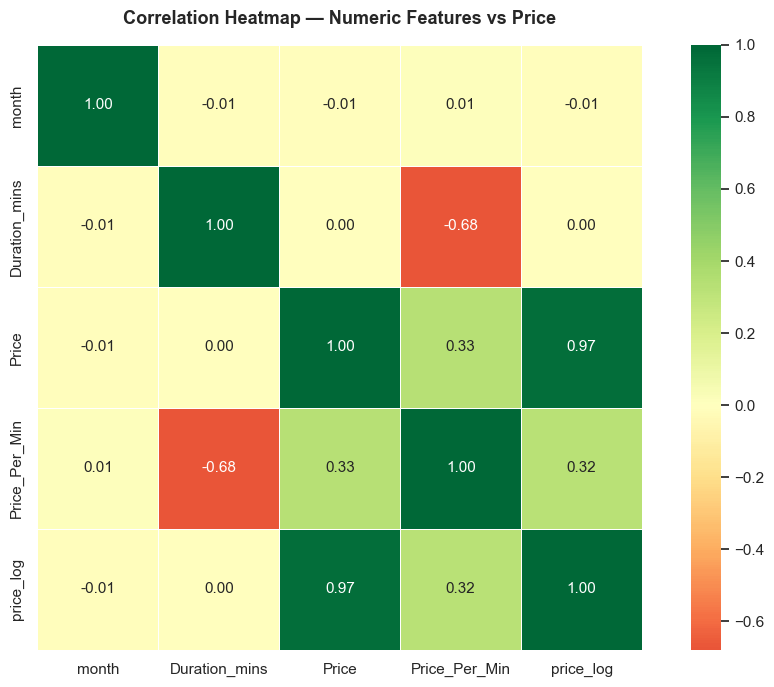

In [9]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID-like columns if present
exclude = ['date_id', 'route_id', 'airline_id', 'flight_id']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Numeric Features vs Price',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

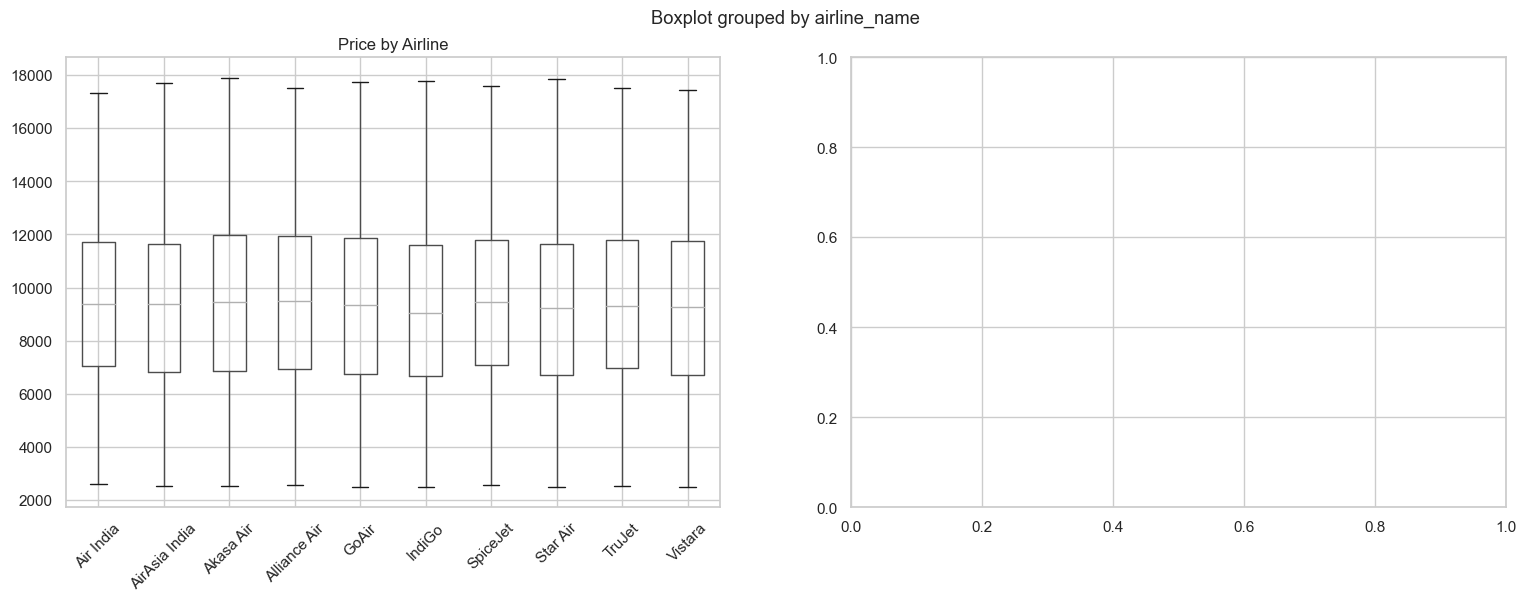

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Price by Airline
df.boxplot(column='Price', by='airline_name', ax=axes[0])
axes[0].set_title('Price by Airline')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Price by Stop Category
stop_order = ['Non-stop', '1 Stop', '2+ Stops']
df_stops = df[df['Total_stops'].isin(stop_order)]
df_stops.boxplot(column='Price', by='Total_stops', ax=axes[1])
axes[1].set_title('Price by Stop Category')
axes[1].set_xlabel('')


plt.suptitle('Price Distribution by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Average price difference between non-stop and 1-stop on same route
route_comparison = df[df['Total_stops'].isin(['Non-stop', '1 Stop'])].copy()

route_pivot = route_comparison.groupby(
    ['Source', 'destination', 'Total_stops']
)['Price'].mean().unstack()

route_pivot.columns = ['Non_stop', 'One_Stop']
route_pivot = route_pivot.dropna()

# Calculate premium
route_pivot['nonstop_premium'] = route_pivot['Non_stop'] - route_pivot['One_Stop']
route_pivot['premium_pct']     = (
    route_pivot['nonstop_premium'] / route_pivot['One_Stop'] * 100
).round(2)

# Routes where non-stop is actually CHEAPER
cheaper_nonstop = route_pivot[route_pivot['nonstop_premium'] < 0].sort_values('nonstop_premium')

print("=== KEY INSIGHT ===")
print(f"Total routes compared: {len(route_pivot)}")
print(f"Routes where non-stop is MORE expensive: {(route_pivot['nonstop_premium'] > 0).sum()}")
print(f"Routes where non-stop is CHEAPER: {(route_pivot['nonstop_premium'] < 0).sum()}")
print(f"\nAverage non-stop premium across all routes: ₹{route_pivot['nonstop_premium'].mean():.2f}")

print(f"\n=== TOP 5 ROUTES WHERE NON-STOP IS CHEAPER ===")
print(cheaper_nonstop[['Non_stop','One_Stop','nonstop_premium','premium_pct']].head())

In [ ]:
# Check exact values first
print(df['Total_stops'].unique())

# Remap whatever your non-stop value is called
stop_remap = {
    '0 stops'  : 'Non-stop',
    'non-stop' : 'Non-stop',
    'nonstop'  : 'Non-stop',
    '1 stop'   : '1 Stop',
    '2 stops'  : '2+ Stops',
    '3 stops'  : '2+ Stops',
    '4 stops'  : '2+ Stops',
}

df['Total_stops'] = df['Total_stops'].str.strip().map(stop_remap).fillna(df['Total_stops'])

# Verify
print(df['Total_stops'].value_counts())

In [ ]:
plt.figure(figsize=(12, 5))
route_pivot['premium_pct'].sort_values().plot(
    kind='bar',
    color=['green' if x < 0 else 'steelblue'
           for x in route_pivot['premium_pct'].sort_values()],
    edgecolor='white'
)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
plt.title('Non-Stop Price Premium % vs 1-Stop — By Route\n'
          '(Green = Non-stop is cheaper on this route)',
          fontsize=12, fontweight='bold')
plt.xlabel('Route')
plt.ylabel('Premium %')
plt.xticks([])   # too many routes to label
plt.legend()
plt.tight_layout()
plt.savefig('nonstop_premium.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Work on a clean copy
model_df = df.copy()

# ─── Drop columns not useful for modelling ────────────────
drop_cols = ['price_log', 'price_per_min', 'day_of_week',
             'month_name', 'season']
model_df  = model_df.drop(columns=[c for c in drop_cols
                                    if c in model_df.columns])

print("Columns remaining:", model_df.columns.tolist())

In [ ]:
# Ordinal because Non-stop < 1 Stop < 2+ Stops has a natural order
stop_map = {'Non-stop': 0, '1 Stop': 1, '2+ Stops': 2}
model_df['stop_encoded'] = model_df['Total_stops'].map(stop_map)

# Check for unmapped values
print("Unmapped stops:", model_df['stop_encoded'].isnull().sum())
print(model_df[['Total_stops','stop_encoded']].drop_duplicates())

In [ ]:
# ✅ Replace with this
model_df['is_weekend'] = model_df['is_weekend'].map({'Yes': 1, 'No': 0})

print("is_weekend unique values:", model_df['is_weekend'].unique())
# Should show: [1 0] or [0 1]

In [ ]:
slot_map = {
    1: 'Early Morning',
    2: 'Morning', 
    3: 'Afternoon',
    4: 'Evening',
    5: 'Night'
}

model_df['dep_slot'] = model_df['dep_slot'].map(slot_map)

# Confirm it worked
print(model_df['dep_slot'].value_counts())

In [ ]:
# Columns to one-hot encode
ohe_cols = ['airline_name', 'Source', 'destination',
            'dep_slot', 'Route_Type']

model_df = pd.get_dummies(model_df, columns=ohe_cols, drop_first=True)

print(f"Shape after encoding: {model_df.shape}")
print(f"Total features created: {model_df.shape[1]}")

In [ ]:
# Target variable
y = model_df['Price']

# Drop target and any remaining non-numeric columns
X = model_df.drop(columns=['Price', 'Total_stops'])

# Make sure everything is numeric
X = X.select_dtypes(include=[np.number])

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeature list:\n{X.columns.tolist()}")

In [ ]:
# ─── Split data ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42      # ensures reproducible results
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

In [ ]:
# ─── Train Random Forest ──────────────────────────────────
model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    random_state=42,
    n_jobs=-1            # use all CPU cores — faster training
)

model.fit(X_train, y_train)
print("Model trained successfully")

In [ ]:
# ─── Predictions ──────────────────────────────────────────
y_pred = model.predict(X_test)

# ─── Metrics ──────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  R² Score : {r2:.4f}")
print(f"  RMSE     : ₹{rmse:,.2f}")
print("=" * 40)

if r2 >= 0.80:
    print("✅ Target achieved — R² > 0.80")
else:
    print("⚠️  Below target — consider tuning")

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title(f'Actual vs Predicted Price\nR² = {r2:.4f} | RMSE = ₹{rmse:,.0f}',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Get feature importances ──────────────────────────────
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# ─── Plot top 20 features ─────────────────────────────────
top20 = importances.tail(20)

plt.figure(figsize=(10, 8))
colors = ['#1F4E79' if i >= len(top20) - 5 else 'steelblue'
          for i in range(len(top20))]
top20.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Top 20 Features by Importance\n"What drives ticket prices?"',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10
print("\n=== TOP 10 PRICING DRIVERS ===")
print(importances.tail(10).sort_values(ascending=False).round(4))